[IPYKERNEL_LAUNCHER]INFO      Starting ANE2-Calibration-SDR v0.1.0 in America/Bogota...
[IPYKERNEL_LAUNCHER]INFO      Starting offline FM calibration from API data...
[IPYKERNEL_LAUNCHER]INFO      Frecuencias FM legales en radio de 10000m: [94.9, 90.9, 96.9, 95.5, 103.9, 92.9, 98.5, 89.9, 104.4, 97.4, 97.9, 100.9, 99.9, 100.4, 102.9, 105.9, 106.9, 91.9, 99.1, 95.9, 90.4, 105.4, 88.9, 92.4, 89.4, 94.4, 88.4, 101.9, 107.9, 104.9, 93.9, 88.1]
[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api
[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['Clean_db'] and nodes: [1]


/tmp/ipykernel_65393/2934975166.py:172: DtypeWarning: Columns (0: potencia, 1: distintivo, 2: expediente, 3: latitud_dec, 4: longitud_dec, 5: fecha_inicial, 6: fecha_final) have mixed types. Specify dtype option on import or set low_memory=False.
  ane_db = pd.read_csv(cfg.SRC_DIR / "db" / "ANE_db_reference.csv")



🚀 Starting Campaign: Clean_db
  ↳ Node 1 loaded instantly from local cache
[IPYKERNEL_LAUNCHER]INFO      Finished loading data for all campaigns and nodes.
[IPYKERNEL_LAUNCHER]INFO      Procesando 100 señales para el Max Hold...
[IPYKERNEL_LAUNCHER]DEBUG     Descartado: 106.214 MHz (Probable pirata/ruido). Legal más cercano a 313.5 kHz
[IPYKERNEL_LAUNCHER]DEBUG     Descartado: 91.213 MHz (Probable pirata/ruido). Legal más cercano a 313.1 kHz
[IPYKERNEL_LAUNCHER]DEBUG     Descartado: 88.216 MHz (Probable pirata/ruido). Legal más cercano a 115.6 kHz
[IPYKERNEL_LAUNCHER]INFO      Match exitoso: 90.882 MHz -> Legal 90.9 MHz (Error: -18.1 kHz)
[IPYKERNEL_LAUNCHER]INFO      Match exitoso: 92.369 MHz -> Legal 92.4 MHz (Error: -31.4 kHz)
[IPYKERNEL_LAUNCHER]INFO      Match exitoso: 88.905 MHz -> Legal 88.9 MHz (Error: 5.4 kHz)
[IPYKERNEL_LAUNCHER]INFO      Match exitoso: 95.911 MHz -> Legal 95.9 MHz (Error: 11.4 kHz)
[IPYKERNEL_LAUNCHER]INFO      Match exitoso: 104.915 MHz -> Legal 104.9 MHz 

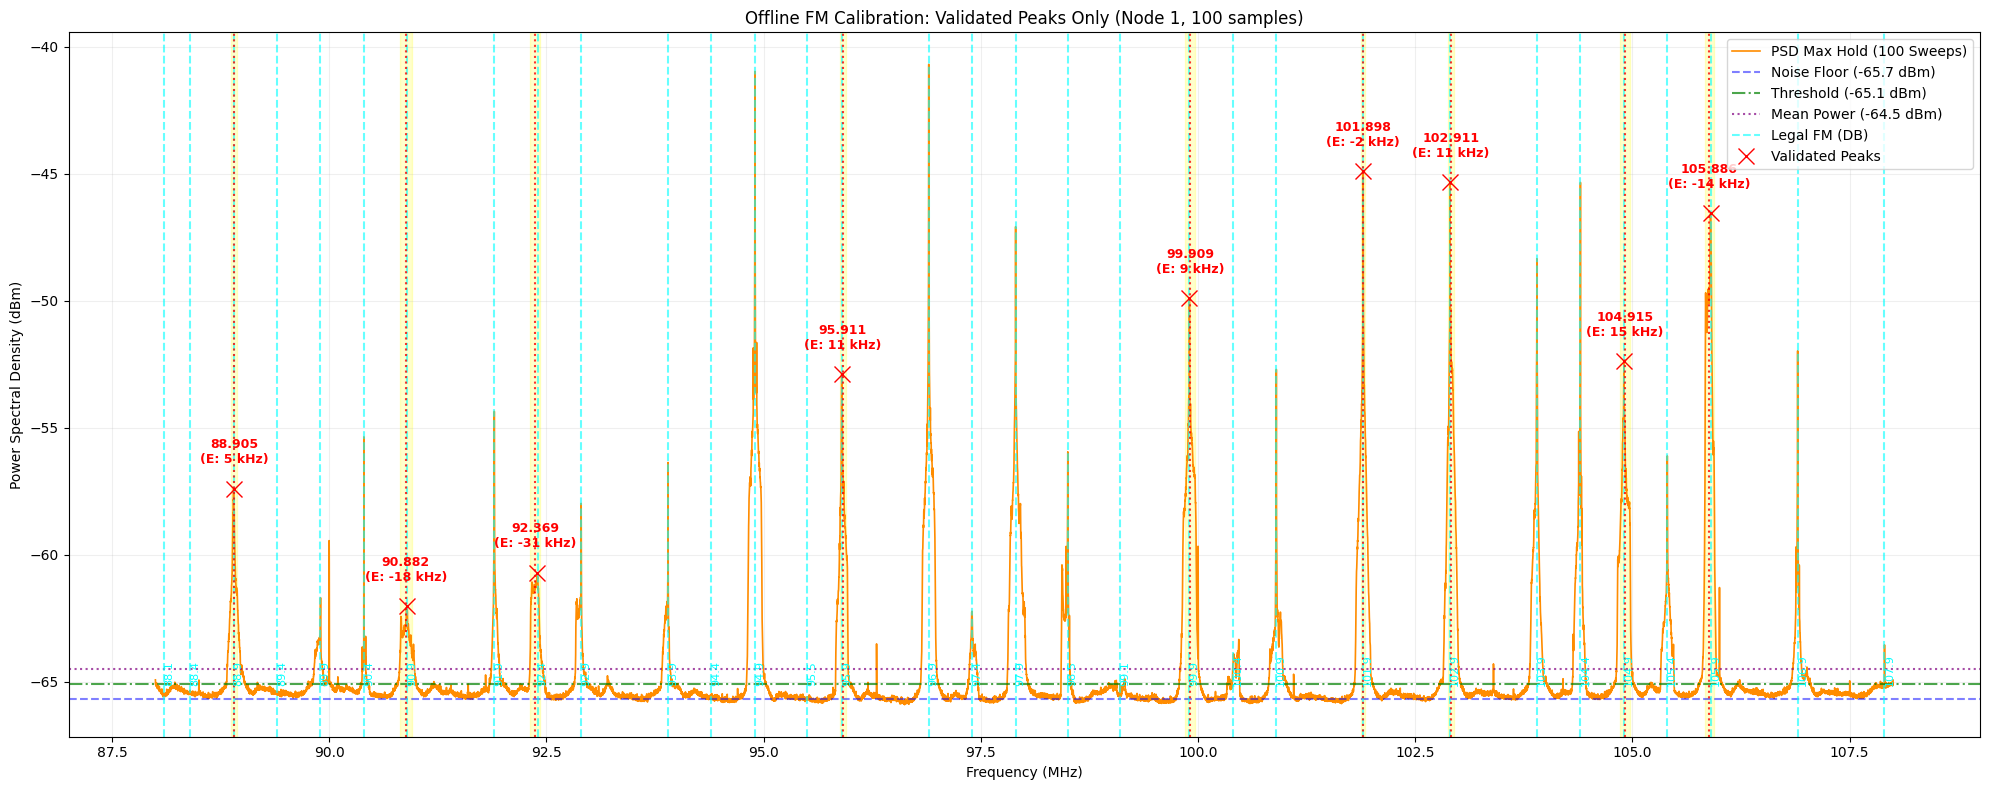

[IPYKERNEL_LAUNCHER]INFO      Offline FM calibration completed with return code: None
[IPYKERNEL_LAUNCHER]INFO      Total execution time: 2.72 seconds


In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import pandas as pd
from dataclasses import dataclass
import time

# Imports de tu proyecto
import cfg
from libs.data_request import DataRequest

log = cfg.set_logger()

@dataclass
class DspPayload:
    start_freq_hz: float
    end_freq_hz: float
    Pxx: np.ndarray

# ---------------------------------------------------------
# FUNCIONES DE PROCESAMIENTO (DSP) Y BASE DE DATOS
# ---------------------------------------------------------

def mask_dc(psd_array: np.ndarray, bin_size_hz: float) -> np.ndarray:
    """Enmascara el pico de DC offset en el centro del espectro."""
    psd_search = psd_array.copy()
    center_idx = len(psd_search) // 2
    
    ignore_bins = int(25e3 / bin_size_hz)
    psd_search[center_idx - ignore_bins : center_idx + ignore_bins] = -np.inf
    
    return psd_search

def floor_and_thres(psd_array: np.ndarray) -> tuple:
    """Calcula el piso de ruido y un umbral dinámico."""
    noise_floor = np.percentile(psd_array, 10)
    mean_power = np.mean(psd_array)
    median_range = np.abs(mean_power - noise_floor)
    threshold = noise_floor + (0.5 * median_range)
    
    return noise_floor, threshold, mean_power

def find_candidates_FM(psd_search: np.ndarray, psd_real: np.ndarray, freq: np.ndarray, 
                       bin_size_hz: float, threshold: float, number_candidates: int = 3) -> list:
    """Detecta los candidatos a portadora filtrando por ancho de banda FWHM y calculando el punto medio.
       Prioriza señales con mayor energía combinada (Potencia + Ancho de banda)."""
    
    # Detección de picos
    peaks, props = find_peaks(psd_search, height=threshold, distance=40)
    
    # NUEVA LÓGICA 1: Medir el ancho a la mitad de la altura del pico (FWHM) para mayor estabilidad
    widths, _, left_ips, right_ips = peak_widths(psd_search, peaks, rel_height=0.5)
    widths_hz = widths * bin_size_hz
    
    # 1. Filtrar por anchos de banda válidos
    # Nota: Como ahora medimos al 50% de caída, los anchos reportados serán más estrechos.
    valid_mask = (widths_hz > 50e3) & (widths_hz <= 225e3)
    orig_indices = np.where(valid_mask)[0]
    
    valid_heights = props['peak_heights'][valid_mask]
    valid_widths = widths_hz[valid_mask]
    
    # 2. Calcular un 'Score' de Energía (Potencia lineal x Ancho de banda)
    power_lin = 10 ** (valid_heights / 10)
    signal_scores = power_lin * valid_widths
    
    # 3. Ordenar basándonos en el score y tomar el top N
    top_sort = np.argsort(signal_scores)[-number_candidates:]
    top_orig_indices = orig_indices[top_sort]
        
    results = []
    for orig_idx in top_orig_indices:
        idx = peaks[orig_idx]
        
        # 4. Calcular los bordes exactos en MHz usando la interpolación sub-bin de SciPy
        left_mhz = freq[0] + (left_ips[orig_idx] * (bin_size_hz / 1e6))
        right_mhz = freq[0] + (right_ips[orig_idx] * (bin_size_hz / 1e6))
        
        # 5. NUEVA LÓGICA 2: Punto Medio Geométrico
        # Ignoramos la asimetría temporal del audio (centro de masa) y promediamos los bordes
        f_center = (left_mhz + right_mhz) / 2.0
        
        results.append((idx, f_center, left_mhz, right_mhz))
        
    return results

def validate_candidates_FM(candidates: list, legal_freqs: list, sensibility: float = 0.1) -> list:
    """
    Cruza los candidatos detectados con la base de datos de frecuencias legales.
    Retorna solo los que están dentro del rango especificado por 'sensibility' (en MHz).
    """
    validated = []
    
    # Si no hay frecuencias legales en la zona, no podemos validar nada
    if not legal_freqs:
        log.warning("No hay frecuencias legales cargadas para comparar.")
        return validated

    for idx, f_center, left_mhz, right_mhz in candidates:
        # Encontrar la frecuencia legal más cercana al centroide detectado
        closest_legal = min(legal_freqs, key=lambda x: abs(x - f_center))
        error_mhz = f_center - closest_legal
        
        # Evaluar contra la sensibilidad (+/- límite)
        if abs(error_mhz) <= sensibility:
            # Guardamos la info original + la frecuencia legal asociada y el error
            validated.append((idx, f_center, left_mhz, right_mhz, closest_legal, error_mhz))
            log.info(f"Match exitoso: {f_center:.3f} MHz -> Legal {closest_legal} MHz (Error: {error_mhz*1000:.1f} kHz)")
        else:
            log.debug(f"Descartado: {f_center:.3f} MHz (Probable pirata/ruido). Legal más cercano a {abs(error_mhz)*1000:.1f} kHz")
            
    return validated

def calculate_global_ppm(validated_candidates: list) -> float:
    """
    Calcula el error mediano en Partes Por Millón (PPM) a partir de los 
    candidatos validados, descartando los valores atípicos (outliers) 
    causados por la modulación asimétrica del audio.
    """
    if not validated_candidates:
        log.warning("No hay candidatos validados para calcular el error PPM.")
        return 0.0

    ppm_errors = []
    for _, centroid_mhz, _, _, legal_mhz, _ in validated_candidates:
        # Calcular el error en PPM para cada pico individual
        ppm = ((centroid_mhz - legal_mhz) / legal_mhz) * 1e6
        ppm_errors.append(ppm)
        
    # La mediana nos da el valor central, ignorando las asimetrías extremas
    global_ppm_error = np.median(ppm_errors)
    
    # También podemos registrar la desviación estándar para ver qué tan dispersos están los datos
    std_dev = np.std(ppm_errors)
    log.info(f"--- Análisis Global de Hardware ---")
    log.info(f"Mediana del Error PPM: {global_ppm_error:.1f} PPM")
    log.info(f"Desviación Estándar de los errores: {std_dev:.1f} PPM")
    
    return global_ppm_error

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def find_coverage_FM(ane_db, coverage_area_m, lat, lng):
    df = ane_db[ane_db["servicio"].astype(str).str.strip() == "Radiodifusión Sonora en FM"].copy()
    df = df.dropna(subset=["frecuencia", "latitud_dec", "longitud_dec"])
    
    df["dist_m"] = haversine_m(lat, lng, df["latitud_dec"].to_numpy(float), df["longitud_dec"].to_numpy(float))
    filtered = df[df["dist_m"] <= coverage_area_m].sort_values("dist_m")
    
    return filtered["frecuencia"].unique().tolist()

# ---------------------------------------------------------
# FLUJO PRINCIPAL DE EJECUCIÓN
# ---------------------------------------------------------

def main():
    log.info("Starting offline FM calibration from API data...")
    
    # 1. Configuración de coordenadas y ANE Database (Bogotá según tu notebook)
    lat, lng = 4.6778, -74.0541
    COVERAGE_AREA_M = 10000

    ane_db = pd.read_csv(cfg.SRC_DIR / "db" / "ANE_db_reference.csv")
    legal_freqs = find_coverage_FM(ane_db, COVERAGE_AREA_M, lat, lng)
    log.info(f"Frecuencias FM legales en radio de {COVERAGE_AREA_M}m: {legal_freqs}")

    # 2. Descargar datos de la API
    camp_ids = {'Clean_db': 278}
    target_nodes = [1]
    dr = DataRequest(log=log, base_url=cfg.API_URL)
    
    df_full = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)
    df_node = df_full['Clean_db']['Node1']
    
    # Validar que tengamos al menos 10 señales
    num_signals_to_process = min(100, len(df_node))
    if num_signals_to_process == 0:
        log.error("No hay señales disponibles para procesar.")
        return 1
        
    log.info(f"Procesando {num_signals_to_process} señales para el Max Hold...")

    # 3. Extraer y apilar las señales para calcular el Max Hold
    psd_captures = []
    start_freq = end_freq = 0
    
    for i, (idx, row) in enumerate(df_node.head(num_signals_to_process).iterrows()):
        psd_captures.append(np.array(row['pxx']))
        # Asumimos que todas las filas de la campaña tienen el mismo span
        if i == 0:
            start_freq = row['start_freq_hz']
            end_freq = row['end_freq_hz']

    # Calcular Max Hold
    psd_matrix = np.vstack(psd_captures)
    psd_max_hold = np.max(psd_matrix, axis=0)
    
    # Crear nuestro objeto Payload
    rf = DspPayload(start_freq_hz=start_freq, end_freq_hz=end_freq, Pxx=psd_max_hold)
    
    freq = np.linspace(rf.start_freq_hz, rf.end_freq_hz, len(rf.Pxx)) / 1e6
    bin_size_hz = (rf.end_freq_hz - rf.start_freq_hz) / len(rf.Pxx)
    
    psd_search = mask_dc(rf.Pxx, bin_size_hz)
    noise_floor, threshold, mean_power = floor_and_thres(rf.Pxx)
    
    # Paso A: Encontrar TODOS los candidatos (buenos y malos)
    raw_candidates = find_candidates_FM(
        psd_search, rf.Pxx, freq, bin_size_hz, threshold, number_candidates=20
    )
    
    # Paso B: Filtrar solo los que hacen match con la ANE (+/- 100 kHz)
    validated_data = validate_candidates_FM(
        raw_candidates, legal_freqs, sensibility=0.1
    )

    # Paso C: NUEVO - Calcular el error global de calibración en PPM
    global_ppm = calculate_global_ppm(validated_data)
    
    if abs(global_ppm) > 5.0:
        log.warning(f"¡Atención! La tarjeta SDR parece tener un desvío significativo.")
        log.warning(f"Configura 'ppm_error={-int(round(global_ppm))}' en tu próximo escaneo.")
    else:
        log.info(f"El hardware parece estar bien calibrado (Error < 5 PPM).")
    
    # 5. Graficar resultados
    plt.figure(figsize=(20, 8))
    plt.plot(freq, rf.Pxx, color='darkorange', linewidth=1.2, label=f'PSD Max Hold ({num_signals_to_process} Sweeps)')
    plt.axhline(noise_floor, color='blue', linestyle='--', alpha=0.5, label=f'Noise Floor ({noise_floor:.1f} dBm)')
    plt.axhline(threshold, color='green', linestyle='-.', alpha=0.7, label=f'Threshold ({threshold:.1f} dBm)')
    plt.axhline(mean_power, color='purple', linestyle=':', alpha=0.7, label=f'Mean Power ({mean_power:.1f} dBm)')
    
    # Frecuencias Legales (ANE)
    visible_legal = [f for f in legal_freqs if freq.min() <= f <= freq.max()]
    for i, f_legal in enumerate(visible_legal):
        label = 'Legal FM (DB)' if i == 0 else ""
        plt.axvline(f_legal, color='cyan', linestyle='--', alpha=0.6, label=label)
        plt.text(f_legal, plt.ylim()[0] + 2, f"{f_legal}", color='cyan', rotation=90, fontsize=8, va='bottom')

    # Picos detectados y VALIDADOS
    if validated_data:
        indices = [item[0] for item in validated_data]
        plt.plot(freq[indices], rf.Pxx[indices], "rx", markersize=12, label='Validated Peaks')
        
        # Ahora desempaquetamos los 6 valores que retorna validate_candidates_FM
        for idx, centroid_mhz, left_mhz, right_mhz, legal_mhz, error_mhz in validated_data:
            plt.axvline(centroid_mhz, color='red', linestyle=':', alpha=0.8)
            plt.axvspan(left_mhz, right_mhz, color='yellow', alpha=0.2)
            
            # Mostramos la frecuencia detectada y el error en kHz
            texto_etiqueta = f"{centroid_mhz:.3f}\n(E: {error_mhz*1000:.0f} kHz)"
            plt.text(centroid_mhz, rf.Pxx[idx] + 1, texto_etiqueta, color='red', weight='bold', ha='center', fontsize=9)

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Power Spectral Density (dBm)")
    plt.title(f"Offline FM Calibration: Validated Peaks Only (Node 1, {num_signals_to_process} samples)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    now = time.perf_counter()
    rc = main() # Como ya no usamos asyncio, lo llamamos directamente
    final_time = time.perf_counter() - now
    log.info(f"Offline FM calibration completed with return code: {rc}")
    log.info(f"Total execution time: {final_time:.2f} seconds")